2025-02-08 23:40:06.355170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739054406.374951  160858 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739054406.381150  160858 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-08 23:40:06.401947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Total classes: 118
Unusable classes: 51
	['ping', 'pwd_mkdb', 'vi', 'tr', 'uname', 'msgs', 'screen', 'pw', 'bzip2', 'bzcat', 'nginx', 'stat', 'tail', 'smtp', 'kenv', 'nawk', 'ssh', 'chown', 'cut', 'php-fpm', 'jot', 'xz', 'diff', 'bounce', 'links', 'ipfw', 'touch', 'env', 'pfctl', 'minions', 'csh', 'kldstat', 'su', 'nohup', 'stty', 'df', 'limits', 'id', 'postmap', 'ifconfig', 'chkgrp', 'ipfstat', 'locale', 'devd', 'uniq', 'XIM', 'getty', 'which', 'init', 'test', 'nice']
Rare classes: 20
	['wc', 'grep', 'mktemp', 'less', 'tty', 'mailwrapper', 'kill', 'lockf', 'mount', 'tee', 'expr', 'ps', 'route', 'sed', 'cmp', 'egrep', 'sort', 'basename', 'awk', 'mail']
Usable classes: 67
Train: 150475
Validation: 32245
Test: 32245
{'adjkerntz': 0, 'alpine': 1, 'anvil': 2, 'atrun': 3, 'awk': 4, 'basename': 5, 'bash': 6, 'cat': 7, 'cleanup': 8, 'cmp': 9, 'cp': 10, 'cron': 11, 'date': 12, 'dd': 13, 'dhclient': 14, 'dmesg': 15, 'egrep': 16, 'expr': 17, 'find': 18, 'fortune': 19, 'grep': 20, 'head': 21, 'ho

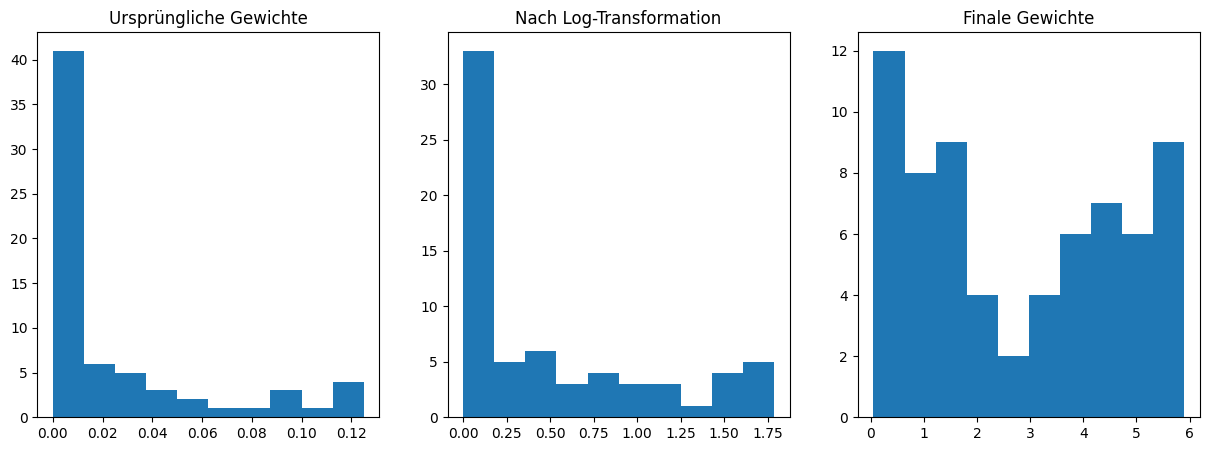


Training Set Statistiken:
Anzahl der Werte: 12688838
Mittelwert: 14227033.07
Standardabweichung: 82036636.81
Median: 6.00
Min: 0.00
Max: 2144920424.00


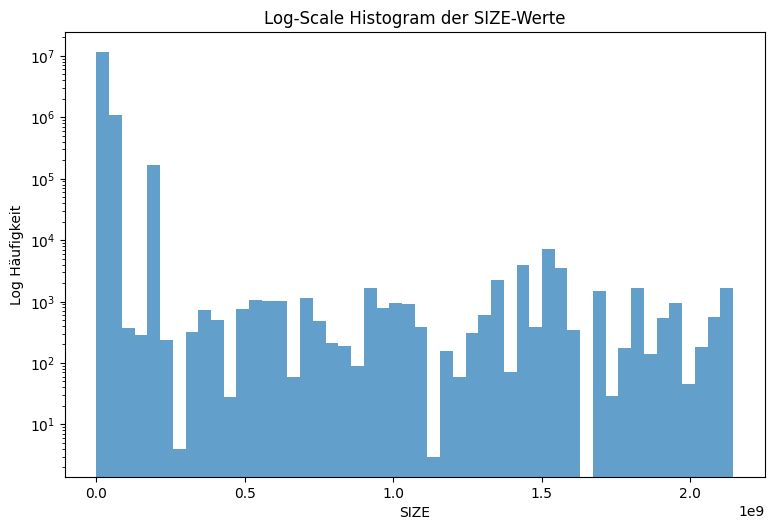


Wertebereiche:
SIZE zwischen -inf und 0: 0 (0.00%)
SIZE zwischen 0 und 1000: 8719443 (68.72%)
SIZE zwischen 1000 und 10000: 967404 (7.62%)
SIZE zwischen 10000 und 100000: 180096 (1.42%)
SIZE zwischen 100000 und inf: 2821895 (22.24%)

Test auf Normalverteilung p-value: 0.0
Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)
Train: 195143
Validation: 39583
Test: 41353
X_train[0] [[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.         -0.17342292  0.
   2.97027802  0.          0.          0.          0.69150335  1.52973974
   0.          0.          3.3184731   0.          0.          0.87207317
   3.30695677  0.          0.          0.          3.47280598  0.
   2.3151474   2.58476567  0.57504863  0.          0.          0.
   0.          0.          0.          0.70897317  0.13242683  2.94519401
   0.          0.          0.          2.98629904  2.88327932  4.87528276
   0.          3.95268607  0.79194558  0.12444903  0.

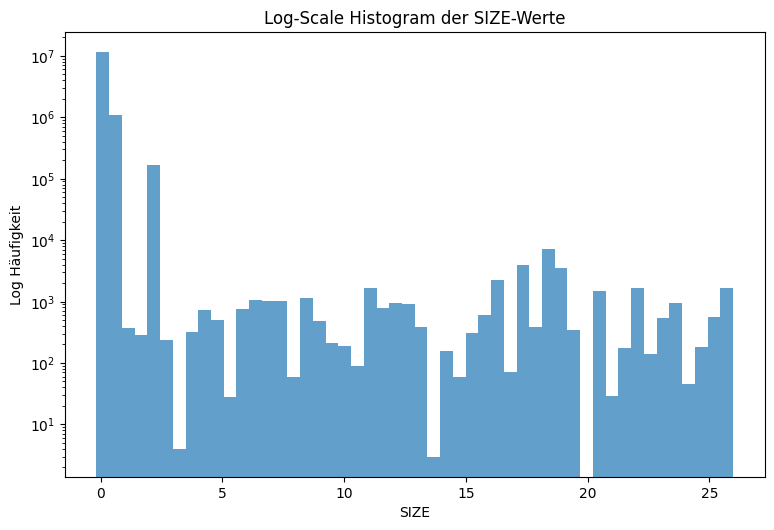


Wertebereiche:
SIZE zwischen -inf und 0: 10879450 (85.74%)
SIZE zwischen 0 und 1000: 1809388 (14.26%)
SIZE zwischen 1000 und 10000: 0 (0.00%)
SIZE zwischen 10000 und 100000: 0 (0.00%)
SIZE zwischen 100000 und inf: 0 (0.00%)

Test auf Normalverteilung p-value: 0.0
Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)
Feature vector cardinality: 107
107


In [1]:
# %% [markdown]
# 

# %%



#imports
import os
import re
from collections import Counter
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch.utils.data import Dataset
import math

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from datetime import datetime
import wandb
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

device = "cuda:1" if torch.cuda.is_available() else "cpu"


os.environ["CUDA_VISIBLE_DEVICES"] = "1"



from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from src.utils.utils import *


# %%
data_directory = '/home/johannes/cadets_jannik'
unusable_threshold = 10
rare_threshold = 50
splits = (0.7, 0.15, 0.15)
total_classes = 0

# unusable classes will be removed from the dataset
unusable_classes = []
# rare classes will be oversampled
rare_classes = []

# all classes in training data (all classes - unusable classes)
classes = []

# walk all files, build unusable_classes, rare_classes
classes_occurrences = Counter()
for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    classes_occurrences[label] += 1

total_classes = len(classes_occurrences)
for label, count in classes_occurrences.items():
    if count < unusable_threshold:
        unusable_classes.append(label)
    elif count < rare_threshold:
        rare_classes.append(label)
        classes.append(label)
    else:
        classes.append(label)

print(f'Total classes: {total_classes}')
print(f'Unusable classes: {len(unusable_classes)}')
print(f'\t{unusable_classes}')
print(f'Rare classes: {len(rare_classes)}')
print(f'\t{rare_classes}')

labels_cardinality = len(set(classes))
print(f'Usable classes: {labels_cardinality}')

# %% [markdown]
# # 

# %%
# split into train, validation, test
labels_set = set()

filenames_all = []

filenames_train = []
filenames_val = []
filenames_test = []

for filename in os.listdir(data_directory):
    label = class_from_filename(filename)
    if label in unusable_classes:
        continue
    labels_set.add(label)
    filenames_all.append(filename)

# stratisfied split
test_vs_val = splits[2] / (splits[1] + splits[2])
filenames_train, filenames_val_test = train_test_split(filenames_all, test_size=splits[1]+splits[2], stratify=[class_from_filename(f) for f in filenames_all])
filenames_val, filenames_test = train_test_split(filenames_val_test, test_size=test_vs_val, stratify=[class_from_filename(f) for f in filenames_val_test])

print(f'Train: {len(filenames_train)}')
print(f'Validation: {len(filenames_val)}')
print(f'Test: {len(filenames_test)}')

# build labels_map in alphabetical order
labels_map = {}
for i, label in enumerate(sorted(labels_set)):
    labels_map[label] = i

# %%
print(labels_map)
class_names = [name for name, idx in sorted(labels_map.items(), key=lambda x: x[1])]
print(class_names)

# %%
# load data
np.set_printoptions(threshold=np.inf)
max_sequence_length = 300
count_files_read = 0
count_sequences_split = 0
count_splits = 0
count = 0

preprocessor = Preprocessor(
    ['TYPE', 'USERNAME', 'PRED_OBJ_PATH_AUTOENC', 'PRED_OBJ_NETINFO', 'SIZE'],
    encode_map='/home/johannes/projects/transformer_bachelor/models/path_encoding_map.pkl'
)

def parse_file(filename) -> tuple[list[int], list[list[int]]]:
    """
    Parse a file and return the vectorized data. Not a pure function (calls parse_line)!
    """
    global count_files_read, count_sequences_split, count_splits
    count = 0
    
    

    y_list: list[int] = []
    X_list: list[list[int]] = []
    y = class_from_filename(filename)
    y = labels_map[y]
    with open(os.path.join(data_directory, filename), 'r') as f:
        lines = f.readlines()
        count_files_read += 1
    if count_files_read % 50000 == 0:
        print(f'Files read: {count_files_read}')
    X = []
    
          
    
    for line in lines:
        
        
    
        line_res = preprocessor.process(line)

        # vectorized data
        event = line_res['TYPE']
        username = line_res['USERNAME']
        pred_obj1_localip = line_res['PRED_OBJ1_LOCALIP']
        pred_obj1_localport = line_res['PRED_OBJ1_LOCALPORT']
        pred_obj1_remoteip = line_res['PRED_OBJ1_REMOTEIP']
        pred_obj1_remoteport = line_res['PRED_OBJ1_REMOTEPORT']
        pred_obj2_localip = line_res['PRED_OBJ2_LOCALIP']
        pred_obj2_localport = line_res['PRED_OBJ2_LOCALPORT']
        pred_obj2_remoteip = line_res['PRED_OBJ2_REMOTEIP']
        pred_obj2_remoteport = line_res['PRED_OBJ2_REMOTEPORT']

        # vectors
        path1 = line_res['PRED_OBJ1_PATH_AUTOENC']
        path2 = line_res['PRED_OBJ2_PATH_AUTOENC']

        # ints
        size = line_res['SIZE']

        res = [event, username, pred_obj1_localip, pred_obj1_localport, pred_obj1_remoteip, pred_obj1_remoteport, pred_obj2_localip, pred_obj2_localport, pred_obj2_remoteip, pred_obj2_remoteport, size]
        res.extend(path1)
        res.extend(path2)
        
        
        
        X.append(res)

    # check if sequence needs to be split
    if len(X) > max_sequence_length:
        count_sequences_split += 1
        count_splits += len(X) // max_sequence_length
        for i in range(0, len(X), max_sequence_length):
            y_list.append(y)
            X_list.append(X[i:i+max_sequence_length])
        assert len(X_list[0]) == max_sequence_length
    else:
        y_list.append(y)
        X_list.append(X)
        

    # transform elements to numpy arrays
    y_list = np.array(y_list)
    X_list = [np.array(x) for x in X_list]

    assert len(y_list) == len(X_list)
    return y_list, X_list


y_train = []
X_train = []
y_val = []
X_val = []
y_test = []
X_test = []

for filename in filenames_train:
    y_list, X_list = parse_file(filename)
    y_train.extend(y_list)
    X_train.extend(X_list)
    
    #for testing purpose
    if(count < 2):
        with open(os.path.join(data_directory, filename), 'r') as f:
            lines = f.readlines()
        
        print(f"filename: {filename}")
        print(f"lines in Filename: {lines}")
        print(f"after Preprocessor: {X_list}")
    count+=1

for filename in filenames_val:
    y_list, X_list = parse_file(filename)
    y_val.extend(y_list)
    X_val.extend(X_list)

for filename in filenames_test:
    y_list, X_list = parse_file(filename)
    y_test.extend(y_list)
    X_test.extend(X_list)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)


print(f'Files read: {count_files_read}')
print(f'Sequences split: {count_sequences_split}')
print(f'Splits: {count_splits}')


event_types_map = preprocessor.event_types_map
users_map = preprocessor.users_map
filetypes_map = preprocessor.filetypes_map
path_map = preprocessor.path_map
addr_map = preprocessor.addr_map
port_map = preprocessor.port_map


event_types_cardinality = len(event_types_map)
users_cardinality = len(users_map)
filetypes_cardinality = len(filetypes_map)
path_cardinality = len(path_map)
addr_cardinality = len(addr_map)
port_cardinality = len(port_map)

print(f'Event types: {event_types_cardinality}')
print(f'Users: {users_cardinality}')
print(f'Filetypes: {filetypes_cardinality}')
print(f'Address: {addr_cardinality}')
print(f'Port: {port_cardinality}')

# print lengths
print(f'Train: {len(y_train)}')
print(f'Validation: {len(y_val)}')
print(f'Test: {len(y_test)}')

#print shape                                         
print(f"X_train[0] {X_train[0]}")                    # Beispielsequnez
print(f"X_train[0][0].shape: {len(X_train[0][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_train[0])}")        # Länge der Sequenz

lengths = set(len(seq[0]) for seq in X_train)
print(f"Unterschiedliche Vektorlängen im Training-Set: {lengths}")

# %%
# one-hot encode labels
y_train = np.eye(labels_cardinality)[y_train]
y_val = np.eye(labels_cardinality)[y_val]
y_test = np.eye(labels_cardinality)[y_test]

print(y_train.shape)

# %%
print("Label shape:", y_train.shape)  # Sollte (batch_size, num_classes) sein, wenn one-hot
print("Beispiel-Label:", y_train[0])  # Muss one-hot Vektor sein (z.B. [0, 1, 0, ...])

# %%
#Berechnung der klassengewichte

# 1. Klassenhäufigkeiten berechnen
class_counts = y_train.sum(axis=0)  # [2, 2, 1]

# 2. Gewichte berechnen
class_weights1 = 1.0 / class_counts  # [0.5, 0.5, 1.0]


# 4. Tensor für PyTorch
weight_tensor1 = torch.tensor(class_weights1, dtype=torch.float32).to(device)

print("Klassen-Gewichte:", weight_tensor1)
# Output: tensor([0.2500, 0.2500, 0.5000])

print(weight_tensor1.shape)

print("Min/Max Gewicht:", weight_tensor1.min().item(), weight_tensor1.max().item())





# %%
#neue Skalierung der Gewichte
from sklearn.utils.class_weight import compute_class_weight

# Annahme: y_train ist one-hot codiert
y_labels = np.argmax(y_train, axis=1)
class_weights2 = compute_class_weight('balanced', classes=np.unique(y_labels), y=y_labels)

# Kritisch: Normalisierung auf Mean=1
class_weights2 = class_weights2 / np.mean(class_weights2)
weight_tensor2 = torch.tensor(class_weights2, dtype=torch.float32).to(device)
print(weight_tensor2)

print("Min/Max Gewicht:", weight_tensor2.min().item(), weight_tensor2.max().item())


# %%
y_labels = np.argmax(y_train, axis=1)
class_weights3 = compute_class_weight('balanced', classes=np.unique(y_labels), y=y_labels)
# Logarithmische Skalierung mit Offset
class_weights3 = np.log1p(class_weights3)
# Begrenzung der Extremwerte
#class_weights3 = np.clip(class_weights3, 0.1, 2.0)
#Normalisierung auf Mittelwert 1
class_weights = class_weights3 / np.mean(class_weights3)
weight_tensor3 = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Min/Max Gewicht:", weight_tensor3.min().item(), weight_tensor3.max().item())
print(weight_tensor3)

# %%
import matplotlib.pyplot as plt

# Ursprüngliche Gewichte
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(class_weights1)
plt.title('Ursprüngliche Gewichte')

# Nach Log-Transformation
plt.subplot(1,3,2)
plt.hist(np.log1p(class_weights2))
plt.title('Nach Log-Transformation')

# Finale Gewichte
plt.subplot(1,3,3)
plt.hist(class_weights3)
plt.title('Finale Gewichte')
plt.show()

# %%
weight_tensor = weight_tensor3

# %%


# %%
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_size_distribution(X_train, X_val, X_test):
    """
    Analysiert die Verteilung der SIZE-Werte in den Datensätzen
    """
    # Sammle alle SIZE-Werte (Index 10)
    sizes_train = []
    sizes_val = []
    sizes_test = []
    
    for sequence in X_train:
        sizes_train.extend(sequence[:, 10])
    for sequence in X_val:
        sizes_val.extend(sequence[:, 10])
    for sequence in X_test:
        sizes_test.extend(sequence[:, 10])
    
    # Konvertiere zu numpy arrays
    sizes_train = np.array(sizes_train)
    sizes_val = np.array(sizes_val)
    sizes_test = np.array(sizes_test)
    
    # Berechne Statistiken
    print("\nTraining Set Statistiken:")
    print(f"Anzahl der Werte: {len(sizes_train)}")
    print(f"Mittelwert: {np.mean(sizes_train):.2f}")
    print(f"Standardabweichung: {np.std(sizes_train):.2f}")
    print(f"Median: {np.median(sizes_train):.2f}")
    print(f"Min: {np.min(sizes_train):.2f}")
    print(f"Max: {np.max(sizes_train):.2f}")
    
    # Erstelle Plots
    plt.figure(figsize=(15, 10))
    
    
    # Log-Scale Histogram
    plt.subplot(2, 2, 2)
    plt.hist(sizes_train, bins=50, alpha=0.7, log=True)
    plt.title('Log-Scale Histogram der SIZE-Werte')
    plt.xlabel('SIZE')
    plt.ylabel('Log Häufigkeit')
    
    
    plt.tight_layout()
    plt.show()
    
    # Zusätzliche Analysen
    print("\nWertebereiche:")
    ranges = [(float('-inf')  , 0), (0, 1000), (1000, 10000), (10000, 100000), (100000, float('inf'))]
    for start, end in ranges:
        count = np.sum((sizes_train >= start) & (sizes_train < end))
        percentage = (count / len(sizes_train)) * 100
        print(f"SIZE zwischen {start} und {end}: {count} ({percentage:.2f}%)")
    
    # Test auf Normalverteilung
    _, p_value = stats.normaltest(sizes_train)
    print(f"\nTest auf Normalverteilung p-value: {p_value}")
    if p_value < 0.05:
        print("Die Verteilung ist wahrscheinlich nicht normal (p < 0.05)")
    else:
        print("Die Verteilung könnte normal sein (p >= 0.05)")

# Verwendung:
analyze_size_distribution(X_train, X_val, X_test)

# %%
from sklearn.preprocessing import StandardScaler

def normalize_size_feature(X_train, X_val, X_test):
    """
    Normalisiert nur das SIZE Feature
    SIZE befindet sich an Index 10 in den Sequenzen
    """
    # Initialisiere Scaler
    size_scaler = StandardScaler()
    
    # Sammle alle SIZE Werte aus dem Training Set
    sizes_train = []
    for sequence in X_train:
        sizes_train.extend(sequence[:, 10].reshape(-1, 1))
    
    # Fit Scaler nur auf Trainingsdaten
    size_scaler.fit(sizes_train)
    
    # Transformationsfunktion für eine einzelne Sequenz
    def transform_sequence(sequence):
        seq_transformed = sequence.copy()
        seq_transformed[:, 10] = size_scaler.transform(sequence[:, 10].reshape(-1, 1)).flatten()
        return seq_transformed
    
    # Transformiere alle Datensätze
    X_train_norm = [transform_sequence(seq) for seq in X_train]
    X_val_norm = [transform_sequence(seq) for seq in X_val]
    X_test_norm = [transform_sequence(seq) for seq in X_test]
    
    return X_train_norm, X_val_norm, X_test_norm

# Verwendung:
X_train, X_val, X_test = normalize_size_feature(X_train, X_val, X_test)

# print lengths
print(f'Train: {len(y_train)}')
print(f'Validation: {len(y_val)}')
print(f'Test: {len(y_test)}')

#print shape                                         
print(f"X_train[0] {X_train[0]}")                    # Beispielsequnez
print(f"X_train[0][0].shape: {len(X_train[0][0])}")  # Länge eines einzelnen Vektors
print(f"X_train[0].shape: {len(X_train[0])}")        # Länge der Sequenz

lengths = set(len(seq[0]) for seq in X_train)
print(f"Unterschiedliche Vektorlängen im Training-Set: {lengths}")

analyze_size_distribution(X_train, X_val, X_test)

# %%


# %%
feature_vector_cardinality = X_train[0].shape[1]
print(f'Feature vector cardinality: {feature_vector_cardinality}')

input_dim = X_train[0][0].shape[0]  # Neue Dimension nach One-Hot-Encoding
print(input_dim)

# %%
class FeatureEmbedding(nn.Module):
    def __init__(
        self,
        d_model: int,
        event_types_cardinality: int = 29,
        users_cardinality: int = 16,
        addr_cardinality: int = 4,
        port_cardinality: int = 9,
        dropout: float = 0.1
    ):
        super().__init__()
        
        # Embedding Dimensionen
        self.event_dim = 32
        self.user_dim = 16
        self.addr_dim = 8
        self.port_dim = 8
        
        # Embeddings für kategorische Features
        self.event_embedding = nn.Embedding(event_types_cardinality, self.event_dim)
        self.user_embedding = nn.Embedding(users_cardinality, self.user_dim)
        self.addr_embedding = nn.Embedding(addr_cardinality, self.addr_dim)
        self.port_embedding = nn.Embedding(port_cardinality, self.port_dim)
        
        # Lineare Projektionen auf d_model
        self.event_proj = nn.Linear(self.event_dim, d_model)
        self.user_proj = nn.Linear(self.user_dim, d_model)
        self.addr_proj = nn.Linear(self.addr_dim, d_model)
        self.port_proj = nn.Linear(self.port_dim, d_model)
        self.size_proj = nn.Linear(1, d_model)
        self.path_proj = nn.Linear(96, d_model)  # 96 = 2 * 48 (PATH_EMBEDDINGS)
        
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)
    
    def embed_network_pair(self, local_ip, local_port, remote_ip, remote_port):
        """Verarbeitet ein Paar von Netzwerk-Features (lokal und remote)"""
        local_ip_emb = self.addr_proj(self.addr_embedding(local_ip))
        local_port_emb = self.port_proj(self.port_embedding(local_port))
        remote_ip_emb = self.addr_proj(self.addr_embedding(remote_ip))
        remote_port_emb = self.port_proj(self.port_embedding(remote_port))
        
        return local_ip_emb + local_port_emb + remote_ip_emb + remote_port_emb
        
    def forward(self, x):
        """
        Input: x shape [batch_size, seq_len, 107]
        Output: shape [batch_size, seq_len, d_model]
        """
        # Basis-Features
        event = x[:, :, 0].long()
        user = x[:, :, 1].long()
        size = x[:, :, 10:11]
        paths = x[:, :, 11:]
        
        # Netzwerk-Features aufteilen
        local_ip1 = x[:, :, 2].long()
        local_port1 = x[:, :, 3].long()
        remote_ip1 = x[:, :, 4].long()
        remote_port1 = x[:, :, 5].long()
        
        local_ip2 = x[:, :, 6].long()
        local_port2 = x[:, :, 7].long()
        remote_ip2 = x[:, :, 8].long()
        remote_port2 = x[:, :, 9].long()
        
        # Basis-Embeddings
        event_emb = self.event_proj(self.event_embedding(event))
        user_emb = self.user_proj(self.user_embedding(user))
        size_emb = self.size_proj(size)
        path_emb = self.path_proj(paths)
        
        # Netzwerk-Embeddings
        net_pair1_emb = self.embed_network_pair(local_ip1, local_port1, remote_ip1, remote_port1)
        net_pair2_emb = self.embed_network_pair(local_ip2, local_port2, remote_ip2, remote_port2)
        netinfo_emb = net_pair1_emb + net_pair2_emb
        
        # Kombiniere alle Features
        combined = (
            event_emb + 
            user_emb + 
            netinfo_emb + 
            size_emb + 
            path_emb
        )
        
        # Normalisierung und Dropout
        output = self.layer_norm(combined)
        output = self.dropout(output)
        
        return output

# %%
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Positional Encoding Matrix berechnen
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        # Registrieren als Buffer (wird mit dem Modell gespeichert)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        """
        Args:
            x: Tensor mit Shape [batch_size, seq_len, d_model]
        """
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# %%
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        model_dim: int,
        num_encoder_layers: int,
        num_heads: int,
        max_len: int,
        dim_feed_forward: int,
        dropout_rate: float,
        activation: str,
        padding_idx: int,
        pos_encoding_scaling: float,
        pooling_type: str,
        norm_first: bool,
        embedding: bool,
        event_types_cardinality,
        users_cardinality,
        addr_cardinality,
        port_cardinality
        
    ):
        super(TransformerEncoder, self).__init__()
        
        self.pooling_type = pooling_type.lower()
        if self.pooling_type not in ["mean", "cls"]:
            raise ValueError("pooling_type muss 'mean' oder 'cls' sein")
        
        # CLS Token nur erstellen wenn nötig
        self.cls_token = nn.Parameter(torch.randn(1, 1, model_dim)) if self.pooling_type == "cls" else None
        
        self.embedding = embedding
        
        if self.embedding:
            self.feature_embedding = FeatureEmbedding(
                d_model=model_dim,
                event_types_cardinality=event_types_cardinality,
                users_cardinality=users_cardinality,
                addr_cardinality=addr_cardinality,
                port_cardinality=port_cardinality,
                dropout=dropout_rate
            )
        else:
            self.input_projection = nn.Linear(input_dim, model_dim)
            self.input_norm = nn.LayerNorm(model_dim)
            
        
        # Positionsencoding länge anpassen wenn CLS Token verwendet wird
        max_len_adjusted = max_len + 1 if self.pooling_type == "cls" else max_len
        self.pos_encoder = PositionalEncoding(model_dim, dropout_rate, max_len_adjusted)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=dim_feed_forward,
            dropout=dropout_rate,
            activation=activation,
            norm_first=norm_first,
            batch_first=True
        )
        
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
            norm=nn.LayerNorm(model_dim)
        )
        
        self.dropout = nn.Dropout(dropout_rate)
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, model_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, num_classes)
        )
        
        self.init_weights()
        self.pos_encoding_scaling = pos_encoding_scaling
        
    def init_weights(self):
        def _init_weights(m):
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
        self.apply(_init_weights)
        # CLS Token separat initialisieren falls vorhanden
        if self.cls_token is not None:
            torch.nn.init.normal_(self.cls_token, std=0.02)
    
    def mean_pooling(self, x: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        mask = attention_mask.unsqueeze(-1).float()
        return torch.sum(x * mask, dim=1) / (torch.sum(mask, dim=1) + 1e-4)
    
    def cls_pooling(self, x: torch.Tensor) -> torch.Tensor:
        return x[:, 0]
        
    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor
    ) -> torch.Tensor:
        batch_size = x.shape[0]
        
        
        #Use Embedding or One Hot Encoding
        if self.embedding:
            x = self.feature_embedding(x)
        else:
            x = self.input_projection(x)
            x = self.input_norm(x)
        
        
        if self.pooling_type == "cls":
            # CLS Token hinzufügen
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
            
            # Attention Mask für CLS Token erweitern
            cls_mask = torch.ones((batch_size, 1), device=attention_mask.device)
            attention_mask = torch.cat((cls_mask, attention_mask), dim=1)
        
        #Anwendung Poitional Encoding
        x = self.pos_encoder(x)
        
        padding_mask = ~attention_mask.bool()
        
        x = self.encoder(x, src_key_padding_mask=padding_mask)
        
        # Pooling basierend auf gewählter Strategie
        if self.pooling_type == "mean":
            x = self.mean_pooling(x, attention_mask)
        else:  # cls
            x = self.cls_pooling(x)
        
        logits = self.classifier(x)
        
        return logits

# %%
class SequenceDataset(Dataset):
    def __init__(self, X, y, fixed_length):
        self.X = X
        self.y = y
        self.fixed_length = fixed_length
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        # Einzelne Sequenz holen
        x = self.X[idx]
        y = self.y[idx]
        
        # Attention Mask erstellen (1 für echte Daten, 0 für padding)
        attention_mask = torch.ones(self.fixed_length)
        
        # Padding/Truncating
        if len(x) < self.fixed_length:
            # Mask auf 0 setzen für Padding-Bereich
            attention_mask[len(x):] = 0
            
            # Padding für die Sequenz
            padding = np.zeros((self.fixed_length - len(x), x.shape[1]))
            x = np.concatenate([x, padding], axis=0)
        else:
            x = x[:self.fixed_length]
            
        x = torch.FloatTensor(x)
        y = torch.FloatTensor([y])
        return x,  y, attention_mask

In [ ]:

from matplotlib.colors import LogNorm
def load_and_evaluate_model(model_path, config, test_loader):
    # Modell initialisieren
    model = TransformerEncoder(
        input_dim=feature_vector_cardinality,
        num_classes=labels_cardinality,
        model_dim=config['model_dim'],
        num_encoder_layers=config['num_encoder_layers'],
        num_heads=config['num_heads'],
        max_len=200,
        dim_feed_forward=4 * config['model_dim'],
        dropout_rate=config['dropout_rate'],
        activation=config['activation'],
        padding_idx=0,
        pos_encoding_scaling=config['pos_encoding_scaling'],
        pooling_type=config['pooling_type'],
        norm_first=config['norm_first'],
        embedding=config['embedding'],
        event_types_cardinality=event_types_cardinality,
        users_cardinality=users_cardinality,
        addr_cardinality=addr_cardinality,
        port_cardinality=port_cardinality
    )

    # Lade gespeicherte Gewichte mit explizitem device mapping
    print(device)
    model.load_state_dict(torch.load(model_path, map_location='cuda:0'))
    model = model.to(device)
    model.eval()

    # Rest der Funktion bleibt gleich
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, targets, attention_masks in test_loader:
            sequences = sequences.to(device)
            targets = targets.to(device)
            attention_masks = attention_masks.to(device)
            
            outputs = model(sequences, attention_masks)
            targets = targets.squeeze(1)
            targets = torch.argmax(targets, dim=1)
            
            predictions = torch.argmax(outputs, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    # Metriken berechnen
    conf_matrix = confusion_matrix(all_labels, all_predictions)
    class_report = classification_report(all_labels, all_predictions, target_names=class_names, digits=3)

    return conf_matrix, class_report

# Verwendung:
config = {
    'activation': 'gelu',
    'batch_size': 128,
    'dropout_rate': 0.2,
    'embedding': True,
    'focal_gamma': 0,
    'l1_lambda': 0,
    'label_smoothing': 0.05,
    'learning_rate': 1e-05,
    'loss_reduction': 'mean',
    'loss_type': 'focal',
    'lr_scheduler': 'ReduceLROnPlateau',
    'model_dim': 512,
    'norm_first': False,
    'num_encoder_layers': 6,
    'num_heads': 4,
    'optimizer': 'adamw',
    'pooling_type': 'cls',
    'pos_encoding_scaling': 1,
    'weight_decay': 0
}

# Testdatensatz erstellen
test_dataset = SequenceDataset(X_test, y_test, 300)
test_loader = DataLoader(test_dataset, 
                        batch_size=128,
                        shuffle=False)

# Modell laden und evaluieren
model_path = "models/toasty-wind-2_905nn2za/model_epoch_31_loss_0.9726.pt"
conf_matrix, class_report = load_and_evaluate_model(model_path, config, test_loader)


# Ergebnisse ausgeben
print("Classification Report:")
print(class_report)

# Confusion Matrix visualisieren
plt.figure(figsize=(20,20))  # Größere Figure Size
sns.heatmap(
    conf_matrix, 
    annot=False,        # Annotations deaktivieren wie im Beispiel
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    norm=LogNorm()  # Logarithmische Normalisierung
)
plt.title('Confusion Matrix - Bestes Modell mit Sequenzlänge 300')  # Angepasster Titel
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Rotiere die Labels
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

# Speichern mit hoher Auflösung
save_path_confusion_matrix = "confusion_matrix_final_test_300.png"  # Pfad anpassen
plt.savefig(
    save_path_confusion_matrix, 
    bbox_inches='tight', 
    dpi=300  # Hohe Auflösung
)
plt.close()  # Figure schließen

# Optional: Zeige die Matrix zusätzlich im Notebook
plt.show()





cuda:1


/tmp/ipykernel_160858/2490131967.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location='cuda:0'))
/tmp/ipykernel_160

Classification Report:
                 precision    recall  f1-score   support

      adjkerntz      0.423     1.000     0.595        11
         alpine      0.951     0.997     0.973       309
          anvil      0.452     0.628     0.526       218
          atrun      1.000     1.000     1.000       237
            awk      1.000     1.000     1.000         5
       basename      0.000     0.000     0.000         2
           bash      0.999     0.998     0.999     12416
            cat      0.926     0.962     0.943        26
        cleanup      1.000     0.522     0.686       157
            cmp      0.833     1.000     0.909         5
             cp      1.000     1.000     1.000        30
           cron      0.990     1.000     0.995       624
           date      1.000     0.999     1.000      1218
             dd      1.000     0.992     0.996       125
       dhclient      0.000     0.000     0.000        12
          dmesg      1.000     1.000     1.000        15
       

: 